# **1. IMPORT LIBRARY**

In [81]:
# LIBRARY UTAMA
import pandas as pd
import numpy as np

# LIBRARY VISUALISASI
import matplotlib.pyplot as plt
import seaborn as sns

# LIBRARY FRAMEWORK
from sklearn.model_selection import train_test_split, GridSearchCV # Untuk Membagi Data Train dan Data Test, # Untuk Mencari Hyperparameter Tuning Terbaik Menggunakan Grid Search digabung Cross Validation  
from sklearn.preprocessing import StandardScaler # Standarisasi Data untuk Model yang sensitif 
from sklearn.compose import ColumnTransformer #
from sklearn.ensemble import RandomForestClassifier # Model Pertama yang Digunakan
from xgboost import XGBClassifier # Model Kedua yang Digunakan
from imblearn.pipeline import Pipeline #
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_auc_score, average_precision_score
# Untuk Evaluasi Tiap Model

# LIBRARY EXPORT MODEL
import joblib

# **2. LOAD DATASET**

In [82]:
# Pembatas 
garis = '=' * 50

# Membaca Dataset
df = pd.read_csv('umkm_prediction_succes_final.csv')
df.head()

,Age,Education,Initial_Capital,Financial_Record_Keeping,Internet_Usage,Business_Plan,Marketing_Effort,Partnership,Parent_Business_Experience,Industry_Experience,Owner_Gender,Professional_Advice,Success
0,32,2,0,1,0,1,6,0,1,10,1,4,1
1,20,1,0,0,0,0,5,1,1,2,0,5,1
2,39,2,0,0,0,1,2,0,1,3,0,1,0
3,35,2,1,1,1,0,5,1,1,9,0,5,1
4,43,4,0,0,0,1,3,1,1,8,1,2,0


Link Kaggle : https://www.kaggle.com/datasets/eskobar/msme-dataset/data

1. Age --> **Numerik (Usia Pelaku UMKM)**
2. Education --> Jenjang Pendidikan --> **Kategorikal : 1=SD, 2=SMP, 3=SMA, 4=Sarjana, dst**
3. Initial_Capital --> Kecukupan Modal Awal --> **Biner : 1=Memadai, 0=Tidak Memadai**
4. Financial_Record_Keeping --> Kualitas Pencatatan Keuangan --> **Biner : 1=Baik, 0=Buruk**
5. Internet Usage --> Pengguna Internet --> **Biner : 1=Iya, 0=Tidak**
6. Business Plan --> Adanya Perencanaan Bisnis --> **Biner : 1=Ada, 0=Tidak Ada**
7. Marketing_Effort --> Tingkat/Usaha Pemasaran --> **Skala Likert : 1-7**
8. Partnership --> Status Kemitraan --> **Biner : 1=Ya, 0=Tidak**
9. Parent_Business_Experience --> Pengalaman Bisnis Orang Tua --> **Biner : 1=Pernah, 0=Tidak Pernah**
10. Industry_Experience --> Pengalaman Pemilik di Industri --> **Numerik (Tahun)**
11. Owner_Gender --> Jenis Kelamin Pemilik --> **Biner : 0=Perempuan, 1=Laki-laki**
12. Professional_Advice --> Frekuensi Konsultasi Profesional --> **Skala Likert : **

# 3. **DATA PREPARATION**

## **3.1 Check Dataset**

In [83]:
print(garis)

data = df.shape[0]
print(f'Total Data yang ada Pada Dataset:{data}')

print(garis)

fitur = df.shape[1] - 1
print(f'Total Fitur yang ada Pada Dataset:{fitur}')

print(garis)

target = df.shape[1] - fitur 
print(f'Total Target yang ada Pada Dataset:{target}')

print(garis)

Total Data yang ada Pada Dataset:5250
Total Fitur yang ada Pada Dataset:12
Total Target yang ada Pada Dataset:1


## **3.2  Check Missing Value dan Handle Missing Value** 

In [84]:
print(garis)

missing = df.isnull().sum()
persentase_missing = (df.isnull().sum() / len(df)) * 100

print(f'Total Data yang Hilang Tiap Fitur:\n{missing}')

print(garis)

print(f'Persentase Data yang Hilang Tiap Fitur:\n{persentase_missing}')

print(garis)

Total Data yang Hilang Tiap Fitur:
Age                           0
Education                     0
Initial_Capital               0
Financial_Record_Keeping      0
Internet_Usage                0
Business_Plan                 0
Marketing_Effort              0
Partnership                   0
Parent_Business_Experience    0
Industry_Experience           0
Owner_Gender                  0
Professional_Advice           0
Success                       0
dtype: int64
Persentase Data yang Hilang Tiap Fitur:
Age                           0.0
Education                     0.0
Initial_Capital               0.0
Financial_Record_Keeping      0.0
Internet_Usage                0.0
Business_Plan                 0.0
Marketing_Effort              0.0
Partnership                   0.0
Parent_Business_Experience    0.0
Industry_Experience           0.0
Owner_Gender                  0.0
Professional_Advice           0.0
Success                       0.0
dtype: float64


## **3.3 Check Duplicate Data dan Handle Duplikat Data**  

In [85]:
print(garis)

duplikat = df.duplicated().sum()
print(f'Total Data yang sama/duplikat:{duplikat}')

print(garis)

print(f'Total Data Setelah dilakukan Handle Duplikat:{data}')
df = df.drop_duplicates()
handle_duplikat = df.shape[0] 
print(f'Total Data Setelah dilakukan Handle Duplikat:{handle_duplikat}')

print(garis)

Total Data yang sama/duplikat:12
Total Data Setelah dilakukan Handle Duplikat:5250
Total Data Setelah dilakukan Handle Duplikat:5238


## **3.4 Check Statistic Data**

In [86]:
print(garis)

statistik = df.describe()
print(f'Data Statistik Tiap Fitur:\n{statistik}')

print(garis)

Data Statistik Tiap Fitur:
               Age    Education  Initial_Capital  Financial_Record_Keeping  \
count  5238.000000  5238.000000      5238.000000               5238.000000   
mean     37.578847     2.610347         0.401489                  0.502291   
std       9.924971     1.090319         0.490246                  0.500042   
min      18.000000     1.000000         0.000000                  0.000000   
25%      30.000000     2.000000         0.000000                  0.000000   
50%      37.000000     3.000000         0.000000                  1.000000   
75%      44.000000     3.000000         1.000000                  1.000000   
max      65.000000     5.000000         1.000000                  1.000000   

       Internet_Usage  Business_Plan  Marketing_Effort  Partnership  \
count     5238.000000    5238.000000       5238.000000  5238.000000   
mean         0.563383       0.590874          3.706186     0.491409   
std          0.496014       0.491719          1.815892   

## **3.5 Check Data Type**

In [87]:
print(garis)

tipe_data = df.dtypes
print(f'Tipe Data Tiap Fitur:\n{tipe_data}')

print(garis)

tipe_kategori = df.select_dtypes(include=['object', 'category', 'string']).columns
print(f'Fitur Apa Saja yang Menggunakan Tipe Data Selain Numerik:\n{tipe_kategori}')
print(garis)

Tipe Data Tiap Fitur:
Age                           int64
Education                     int64
Initial_Capital               int64
Financial_Record_Keeping      int64
Internet_Usage                int64
Business_Plan                 int64
Marketing_Effort              int64
Partnership                   int64
Parent_Business_Experience    int64
Industry_Experience           int64
Owner_Gender                  int64
Professional_Advice           int64
Success                       int64
dtype: object
Fitur Apa Saja yang Menggunakan Tipe Data Selain Numerik:
Index([], dtype='str')


## **3.6 Analysis Outlier**

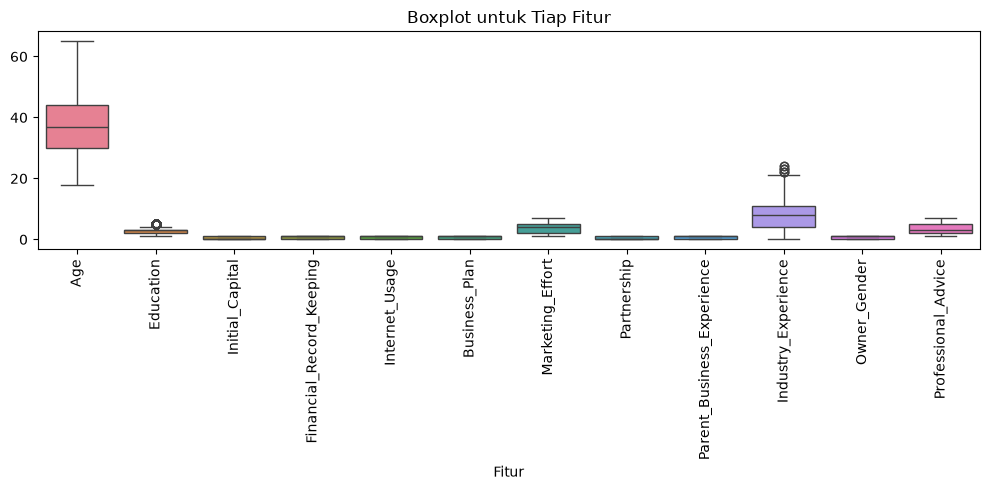

In [88]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.iloc[:, :-1])
plt.xlabel('Fitur')
plt.title('Boxplot untuk Tiap Fitur')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Ketika Ada Outlier Jangan Langsung Dihapus tetapi Lakukan Analisis Apakah Data nya emang ada di dunia nyata.
# Jika Ada Biarkan saja, Jika Tidak Masuk Akal Nilainya bisa lakukan capping atau drop

## **3.7 Check Distribution Data Target (Balance or Imbalanced)**

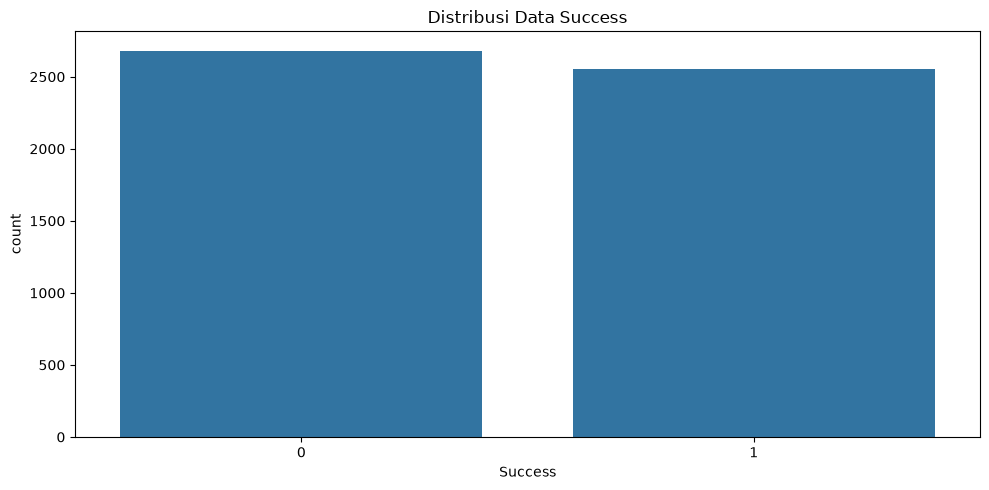

Success
0    2681
1    2557
Name: count, dtype: int64

In [89]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Success', data=df)
plt.title('Distribusi Data Success')
plt.tight_layout()
plt.show()
df['Success'].value_counts()
# Target Imbalanced (Tidak Seimbang)

## **3.8 Check Distribution Data Fitur**

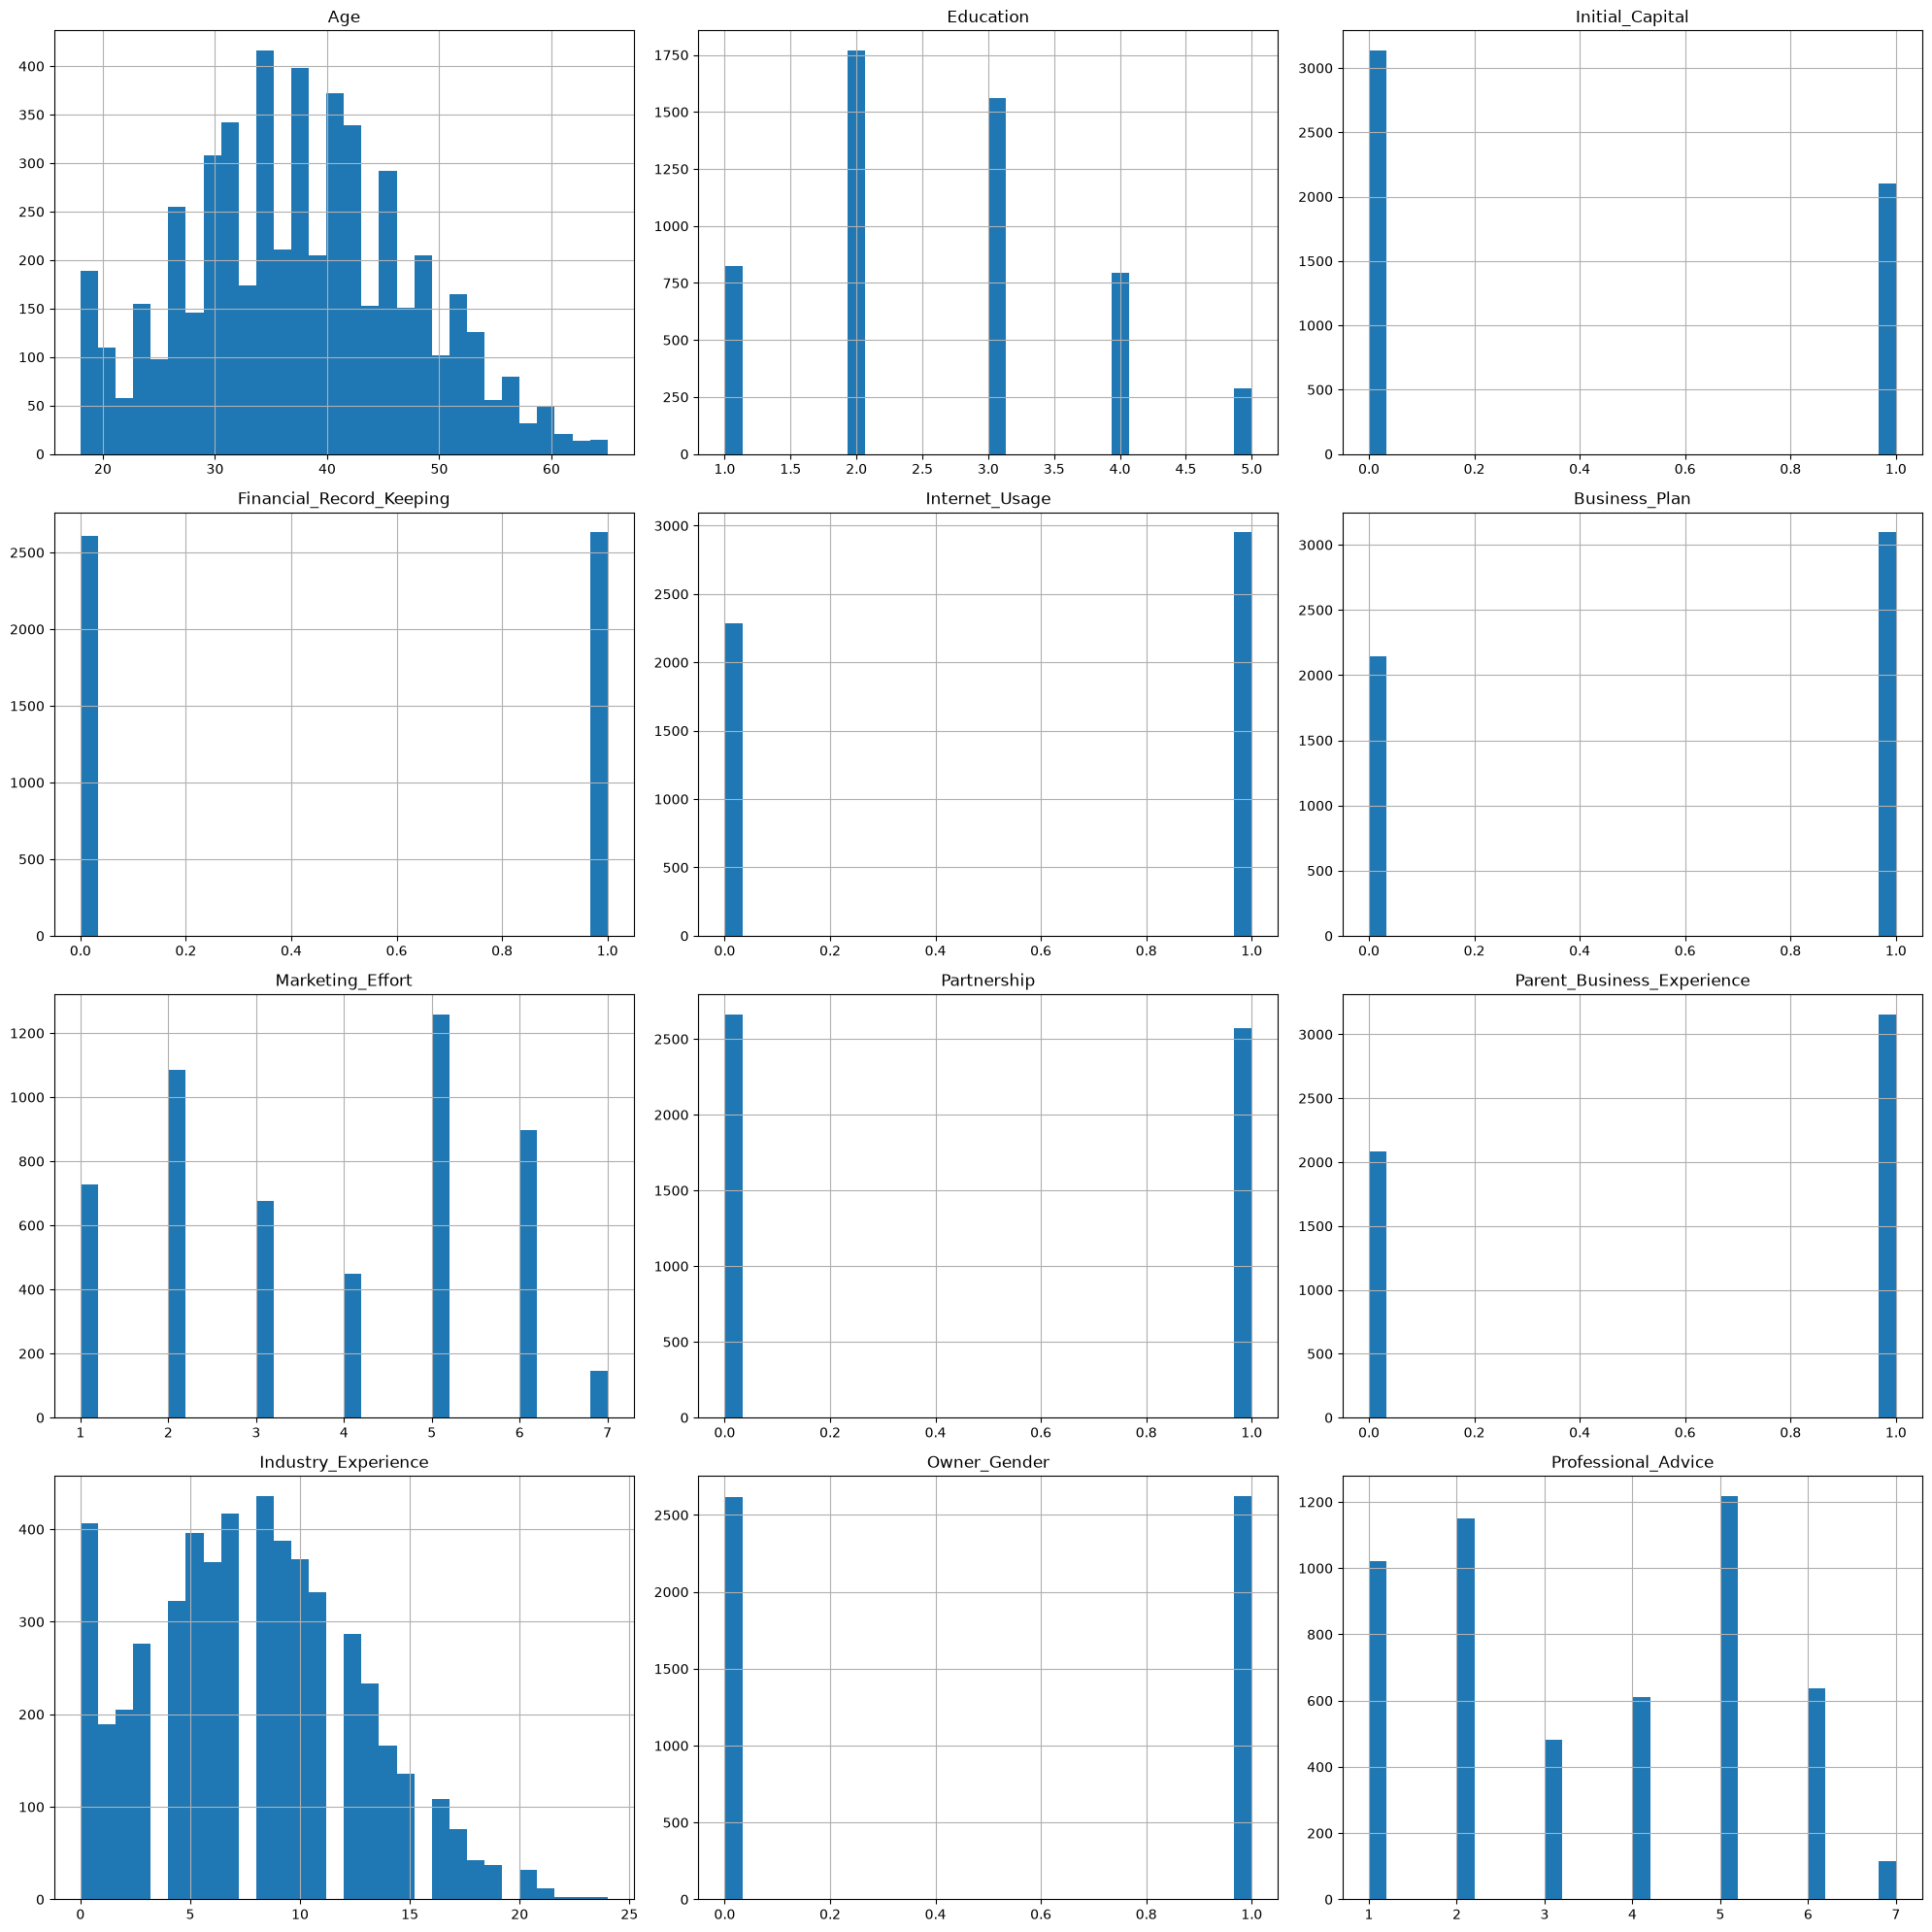

In [90]:
df.iloc[:, :-1].hist(figsize=(20, 20), bins=30)
plt.tight_layout()
plt.show()

## **3.9 Check Correlation Feature**

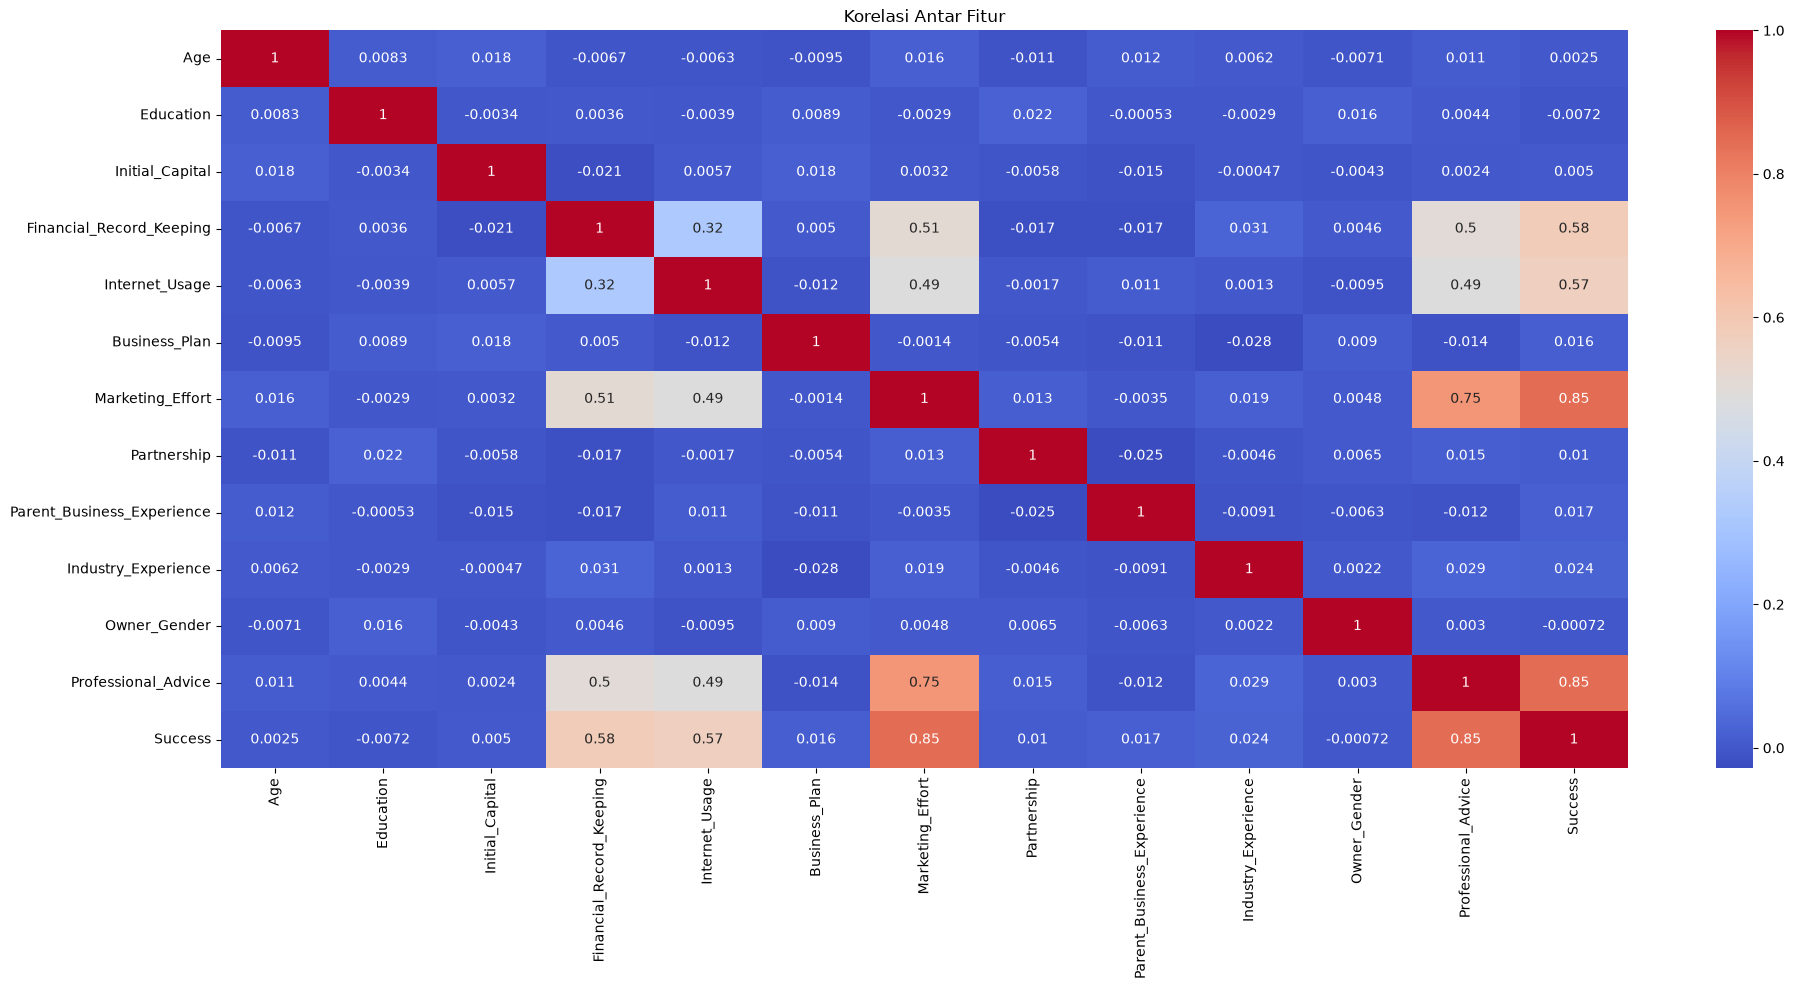

In [91]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.show()
# Semakin Mendekati Angka 1 Maka Semakin Kuat Hubungan Antar Fitur

## **3.10 Fitur VS Target**

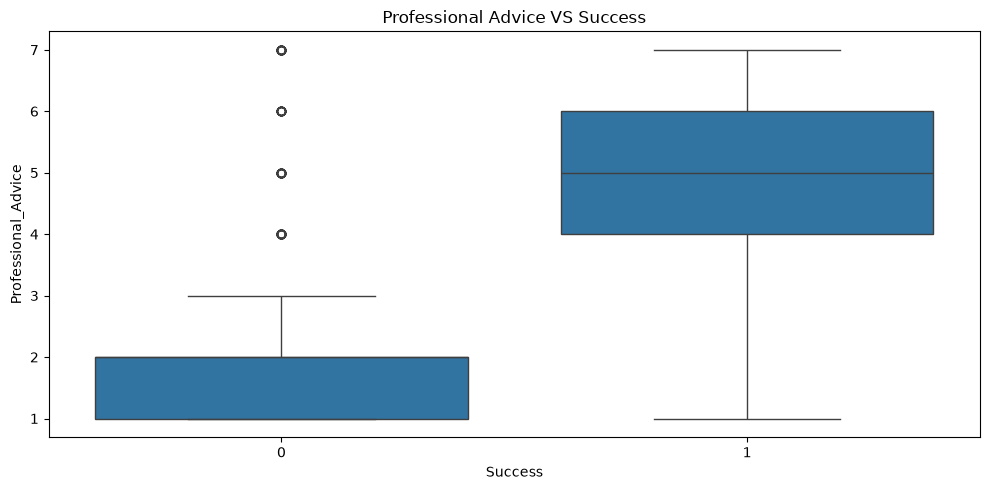

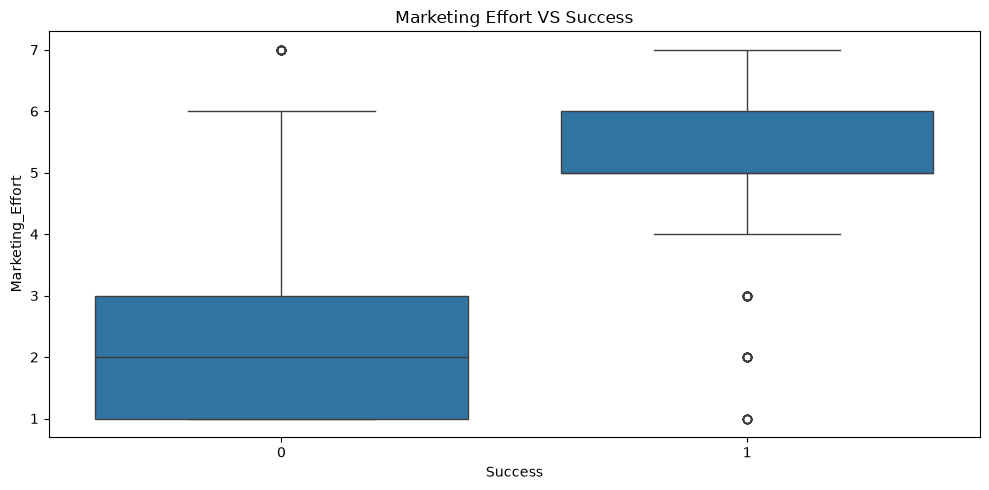

In [92]:
# Ambil Fitur Yang Paling Kuat Hubungannya Untuk Menghasilkan Target
plt.figure(figsize=(10, 5))
sns.boxplot(x='Success', y='Professional_Advice', data=df)
plt.title('Professional Advice VS Success')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='Success', y='Marketing_Effort', data=df)
plt.title('Marketing Effort VS Success')
plt.tight_layout()
plt.show()

# **4. PREPROCESSING**

## **4.1 Pisah Fitur dan Target**

In [93]:
X = df.drop('Success', axis=1)
y = df['Success']
y

0       1
1       1
2       0
3       1
4       0
       ..
5245    0
5246    0
5247    0
5248    0
5249    1
Name: Success, Length: 5238, dtype: int64

## **4.2 Split Data**

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## **4.3 Fitur Transformasi untuk Pipeline**

In [95]:
numerik = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessing = ColumnTransformer([
    ('Num', StandardScaler(),
     numerik
    )
])
# UNTUK MODEL YANG HARUS MELAKUKAN STANDARISASI/NORMALISASI PADA DATA 

# **5. MODELING**

## **5.1 Random Forest**

In [96]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

rf_params = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
    "model__criterion": ["gini", "entropy"]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

## **5.2 XGBoost**

In [97]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline([
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale
    ))
])

xgb_params = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8],
    "model__min_child_weight": [3],
    "model__gamma": [0.1],
    "model__reg_alpha": [0.1],
    "model__reg_lambda": [1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

## **5.3 Training**

In [98]:
models = {
    "Random Forest": rf_grid,
    "XGBoost": xgb_grid
}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    print(f"\n{name} selesai")
    print("Best Params:")
    print(model.best_params_)

    print("Best CV F1:")
    print(model.best_score_)

rf_pred = rf_grid.predict(X_test)
xgb_pred = xgb_grid.predict(X_test)


Training Random Forest...

Random Forest selesai
Best Params:
{'model__criterion': 'gini', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best CV F1:
0.9798206130805683

Training XGBoost...

XGBoost selesai
Best Params:
{'model__colsample_bytree': 0.8, 'model__gamma': 0.1, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__min_child_weight': 3, 'model__n_estimators': 200, 'model__reg_alpha': 0.1, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}
Best CV F1:
0.9805564190328576


# **6. EVALUASI MODEL**

## **6.1 Akurasi Presisi Recall F1**

In [99]:
print(garis)
print('Membandingkan 2 Performa Model:')
for name, pred in [('Random Forest', rf_pred), ('XGBoost', xgb_pred)]:
    print(f"--- {name} ---")
    print("Akurasi  :", round(accuracy_score(y_test, pred), 3))
    print("Precision:", round(precision_score(y_test, pred, zero_division=0), 3))
    print("Recall   :", round(recall_score(y_test, pred, zero_division=0), 3))
    print("F1-score :", round(f1_score(y_test, pred, zero_division=0), 3))

    print()
print(garis)

Membandingkan 2 Performa Model:
--- Random Forest ---
Akurasi  : 0.986
Precision: 0.979
Recall   : 0.992
F1-score : 0.985

--- XGBoost ---
Akurasi  : 0.987
Precision: 0.983
Recall   : 0.99
F1-score : 0.986



## **6.2 Confusion Matrix**

### 6.2.1 Random Forest

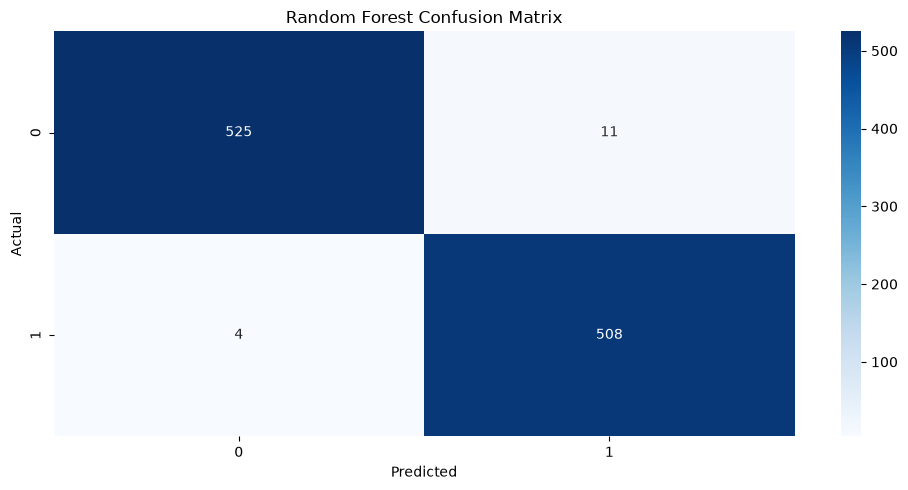

In [100]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 6.2.2 XGBoost

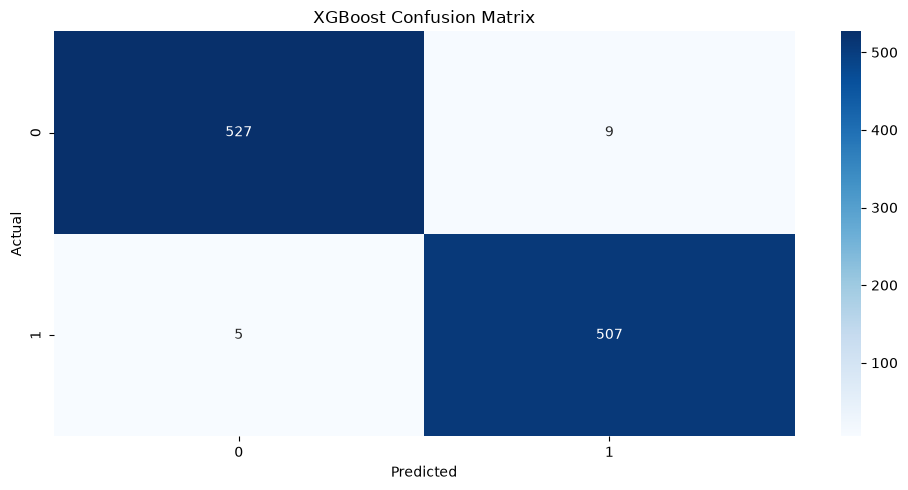

In [101]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(10, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## **6.3 Classification Report**

In [102]:
print(garis)

print('Random Forest')
print(classification_report(y_test, rf_pred))

print(garis)

print('XGBoost')
print(classification_report(y_test, xgb_pred))

print(garis)

Random Forest
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       536
           1       0.98      0.99      0.99       512

    accuracy                           0.99      1048
   macro avg       0.99      0.99      0.99      1048
weighted avg       0.99      0.99      0.99      1048

XGBoost
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       536
           1       0.98      0.99      0.99       512

    accuracy                           0.99      1048
   macro avg       0.99      0.99      0.99      1048
weighted avg       0.99      0.99      0.99      1048



## **6.4 ROC-AUC**

### 6.4.1 Random Forest

In [103]:
y_prob_rf = rf_grid.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(garis)
print('AUC XGBoost:', auc_rf)
print(garis)

AUC XGBoost: 0.9987173507462687


### 6.4.2 XGBoost

In [104]:
y_prob_xgb = xgb_grid.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(garis)
print('AUC XGBoost:', auc_xgb)
print(garis)

AUC XGBoost: 0.9986007462686567


## 6.5 PR-AUC

### 6.5.1 Random Forest

In [105]:
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print(garis)
print('PR-AUC XGBoost:', pr_auc_rf)
print(garis)

PR-AUC XGBoost: 0.9986136435850473


### 6.5.2 XGBoost

In [106]:
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print(garis)
print('PR-AUC XGBoost:', pr_auc_xgb)
print(garis)

PR-AUC XGBoost: 0.998435568660129


In [107]:
import joblib
from sklearn.metrics import f1_score

rf_pred = rf_grid.predict(X_test)
xgb_pred = xgb_grid.predict(X_test)

f1_rf = f1_score(y_test, rf_pred)
f1_xgb = f1_score(y_test, xgb_pred)

print(f"F1 Random Forest : {f1_rf:.4f}")
print(f"F1 XGBoost       : {f1_xgb:.4f}")

if f1_rf >= f1_xgb:
    best_model = rf_grid.best_estimator_
    print("Model terbaik: Random Forest")
else:
    best_model = xgb_grid.best_estimator_
    print("Model terbaik: XGBoost")

joblib.dump(best_model, 'model_umkm_xgboost')
print("Model telah disimpan.")

F1 Random Forest : 0.9855
F1 XGBoost       : 0.9864
Model terbaik: XGBoost
Model telah disimpan.


F1 Random Forest : 0.9855
F1 XGBoost       : 0.9864
Model terbaik: XGBoost
Model telah disimpan.


In [ ]:
joblib.dump(rf_grid.best_estimator_, 'model_umkm')
print("Berhasil disimpan.")